## 1. ПОДГОТОВКА ДАННЫХ

В этом разделе мы:
- Загружаем данные из файлов `ga_sessions.csv` 
- Изучаем структуру и атрибуты
- Проверяем полноту, чистоту данных
- Обрабатываем пропуски и дубликаты
- Приводим данные к удобному виду

In [1]:
# импорт библиотек
import pandas as pd
import numpy as np
import gc


### Загрузка данных

**Описание атрибутов сессий:**
- `session_id` — ID визита
- `client_id` — ID посетителя
- `visit_date` — дата визита
- `visit_time` — время визита
- `visit_number` — порядковый номер визита
- `utm_source` — канал привлечения
- `utm_medium` — тип привлечения
- `utm_campaign` — рекламная кампания
- `utm_keyword` — ключевое слово
- `device_category` — тип устройства
- `device_os` — ОС устройства
- `device_brand` — марка устройства
- `device_model` — модель устройства
- `device_screen_resolution` — разрешение экрана
- `device_browser` — браузер
- `geo_country` — страна
- `geo_city` — город

Загружаем данные из CSV-файлов.

In [2]:
# Загрузка
# Данные лежат в ..data/
DATA_PATH = '../data/'

sessions = pd.read_csv(f'{DATA_PATH}ga_sessions.csv')


/tmp/ipykernel_137396/2392030422.py:5: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  sessions = pd.read_csv(f'{DATA_PATH}ga_sessions.csv')


In [3]:
sessions

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.163776,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.162225,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.162225,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1860037,9055415581448263752.1640159305.1640159305,2108378238.164016,2021-12-22,10:48:25,1,BHcvLfOaCWvWTykYqHVe,cpc,NaN,NaN,VlqBmecIOXWjCWUmQkLd,desktop,Windows,NaN,NaN,1920x1080,Chrome,Russia,Moscow
1860038,9055421130527858185.1622007305.1622007305,2108379530.162201,2021-05-26,08:00:00,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,NaN,mobile,NaN,Apple,NaN,390x844,Safari,Russia,Stavropol
1860039,9055422955903931195.1636979515.1636979515,2108379955.163697,2021-11-15,15:31:55,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,iOS,Apple,NaN,375x667,Safari,Russia,Moscow
1860040,905543020766873816.1638189404.1638189404,210838164.163819,2021-11-29,15:36:44,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,Android,Xiaomi,NaN,393x851,Chrome,Russia,Chelyabinsk


#### Структура данных

In [4]:
sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 18 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   session_id                object
 1   client_id                 object
 2   visit_date                object
 3   visit_time                object
 4   visit_number              int64 
 5   utm_source                object
 6   utm_medium                object
 7   utm_campaign              object
 8   utm_adcontent             object
 9   utm_keyword               object
 10  device_category           object
 11  device_os                 object
 12  device_brand              object
 13  device_model              object
 14  device_screen_resolution  object
 15  device_browser            object
 16  geo_country               object
 17  geo_city                  object
dtypes: int64(1), object(17)
memory usage: 255.4+ MB


### ПРОВЕРКА НА ПРОПУСКИ И ДУБЛИКАТЫ

##### Пропуски

In [5]:
sessions.isnull().sum()[sessions.isnull().sum() > 0]

utm_source            97
utm_campaign      219603
utm_adcontent     335615
utm_keyword      1082061
device_os        1070138
device_brand      367178
device_model     1843704
dtype: int64

**Выводы:**
- Большое количество пропусков в колонках, связанных с устройствами и UTM-метками
- Пропуски будут заполнены значением `'unknown'`

##### Дубликаты

In [6]:
sessions.duplicated().sum()

np.int64(0)

In [7]:
sessions['session_id'].nunique()


1860042

**Вывод:** Дубликаты отсутствуют, удаление не требуется.

### ОБРАБОТКА ПРОПУСКОВ

##### Обработка пропусков в сессиях

Заполняем пропуски:
- UTM-поля → `'unknown'`
- Устройства (`device_os`, `device_brand`, `device_model`, `device_browser`) → `'unknown'`
- Гео-поля → `'unknown'`
- Преобразуем `visit_date` в формат `datetime`

In [6]:
# UTM поля
utm_cols = ['utm_source', 'utm_medium', 'utm_campaign', 'utm_adcontent', 'utm_keyword']
for col in utm_cols:
    sessions[col] = sessions[col].fillna('unknown')
    sessions[col] = sessions[col].replace('(none)', 'unknown')

# Устройства
device_cols = ['device_os', 'device_brand', 'device_model', 'device_browser']
for col in device_cols:
    sessions[col] = sessions[col].fillna('unknown')

# Гео
geo_cols = ['geo_country', 'geo_city']
for col in geo_cols:
    sessions[col] = sessions[col].fillna('unknown')

# Типизация дат
sessions['visit_date'] = pd.to_datetime(sessions['visit_date'])

In [9]:
sessions

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.163776,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,unknown,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,unknown,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,unknown,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.162225,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,unknown,NOBKLgtuvqYWkXQHeYWM,unknown,mobile,unknown,Xiaomi,unknown,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.162225,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,unknown,unknown,unknown,mobile,unknown,Xiaomi,unknown,393x786,Chrome,Russia,Moscow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1860037,9055415581448263752.1640159305.1640159305,2108378238.164016,2021-12-22,10:48:25,1,BHcvLfOaCWvWTykYqHVe,cpc,unknown,unknown,VlqBmecIOXWjCWUmQkLd,desktop,Windows,unknown,unknown,1920x1080,Chrome,Russia,Moscow
1860038,9055421130527858185.1622007305.1622007305,2108379530.162201,2021-05-26,08:00:00,1,fDLlAcSmythWSCVMvqvL,unknown,LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,unknown,mobile,unknown,Apple,unknown,390x844,Safari,Russia,Stavropol
1860039,9055422955903931195.1636979515.1636979515,2108379955.163697,2021-11-15,15:31:55,1,fDLlAcSmythWSCVMvqvL,unknown,LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,iOS,Apple,unknown,375x667,Safari,Russia,Moscow
1860040,905543020766873816.1638189404.1638189404,210838164.163819,2021-11-29,15:36:44,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,Android,Xiaomi,unknown,393x851,Chrome,Russia,Chelyabinsk


**Результат обработки сессий:**
- Все пропуски заполнены
- Дата приведена к типу `datetime`
- Данные готовы к объединению с хитами

### Загрузка hits

**Описание атрибутов хитов (событий):**
- `session_id` — ID визита
- `hit_date` — дата события
- `hit_time` — время события
- `hit_number` — порядковый номер события
- `hit_type` — тип события
- `hit_referer` — источник события
- `hit_page_path` — страница события
- `event_category` — тип действия
- `event_action` — действие
- `event_label` — тег действия
- `event_value` — значение результата действия


### Агрегация хитов по сессиям

**Способ обработки:** Чанкинг (по 500,000 строк) для экономии памяти.

In [7]:
print("Агрегация всех признаков из hits...")

chunk_size = 500000
hits_agg_list = []
catalog_agg_list = []
order_agg_list = []
event_agg_list = []

for chunk in pd.read_csv(DATA_PATH + 'ga_hits.csv',
                         usecols=['session_id', 'hit_number', 'hit_page_path', 
                                  'event_category', 'event_action'],
                         chunksize=chunk_size):
    
    # Фильтруем хиты с сессиями
    chunk = chunk[chunk['session_id'].isin(sessions['session_id'])]
    
    # 1. Базовые агрегаты
    agg = chunk.groupby('session_id').agg({
        'hit_number': 'count',
        'hit_page_path': 'nunique',
        'event_category': 'nunique'
    }).rename(columns={
        'hit_number': 'total_events',
        'hit_page_path': 'unique_pages',
        'event_category': 'unique_event_types'
    })
    hits_agg_list.append(agg)
    
    # 2. Посещения каталога
    catalog = chunk[chunk['hit_page_path'].str.contains('/catalog', na=False)]\
                     .groupby('session_id').size().reset_index(name='catalog_visits')
    if not catalog.empty:
        catalog_agg_list.append(catalog)
    
    # 3. Посещения страницы заказа
    order = chunk[chunk['hit_page_path'].str.contains('/order', na=False)]\
                   .groupby('session_id').size().reset_index(name='order_visits')
    if not order.empty:
        order_agg_list.append(order)
    
    # 4. Целевые события (из глоссария)
    target_categories = [
        'sub_submit', 'greenday_sub_submit', 'chat', 
        'phone', 'add_ad_publish_success', 'add_ad_form'
    ]
    
    target = chunk[chunk['event_category'].isin(target_categories)]\
                   .groupby('session_id').size().reset_index(name='target_events')
    if not target.empty:
        event_agg_list.append(target)
        
    del chunk, agg, catalog, order, target
    gc.collect()


Агрегация всех признаков из hits...


In [8]:
# Объединяем все агрегаты
print("Объединение результатов...")

hits_agg = pd.concat(hits_agg_list).groupby('session_id').sum()
catalog_agg = pd.concat(catalog_agg_list).groupby('session_id').sum().reset_index() if catalog_agg_list else pd.DataFrame({'session_id': [], 'catalog_visits': []})
order_agg = pd.concat(order_agg_list).groupby('session_id').sum().reset_index() if order_agg_list else pd.DataFrame({'session_id': [], 'order_visits': []})
event_agg = pd.concat(event_agg_list).groupby('session_id').sum().reset_index() if event_agg_list else pd.DataFrame({'session_id': [], 'target_events': []})

# Присоединяем все к сессиям
sessions = sessions.merge(hits_agg, on='session_id', how='left')
sessions = sessions.merge(catalog_agg, on='session_id', how='left')
sessions = sessions.merge(order_agg, on='session_id', how='left')
sessions = sessions.merge(event_agg, on='session_id', how='left')
sessions = sessions.fillna(0)

# Создаем бинарные признаки
sessions['has_catalog_view'] = (sessions['catalog_visits'] > 0).astype(int)
sessions['has_order_view'] = (sessions['order_visits'] > 0).astype(int)

del hits_agg, catalog_agg, order_agg, event_agg
gc.collect()

Объединение результатов...


0

In [9]:
# Создаем target
sessions['target'] = (sessions['target_events'] > 0).astype(int)

In [13]:
sessions.shape

(1860042, 27)

In [14]:
sessions.head()

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,...,geo_city,total_events,unique_pages,unique_event_types,catalog_visits,order_visits,target_events,has_catalog_view,has_order_view,target
0,9055434745589932991.1637753792.1637753792,2108382700.163776,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,...,Zlatoust,2.0,1.0,2.0,0.0,0.0,0.0,0,0,0
1,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,...,Moscow,1.0,1.0,1.0,0.0,0.0,0.0,0,0,0
2,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,...,Krasnoyarsk,16.0,10.0,10.0,0.0,0.0,0.0,0,0,0
3,9055447046360770272.1622255328.1622255328,2108385564.162225,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,unknown,NOBKLgtuvqYWkXQHeYWM,unknown,...,Moscow,3.0,1.0,2.0,0.0,0.0,0.0,0,0,0
4,9055447046360770272.1622255345.1622255345,2108385564.162225,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,unknown,unknown,unknown,...,Moscow,2.0,1.0,2.0,0.0,0.0,0.0,0,0,0


**Итог по подготовке данных:**

**Загрузка:** Данные загружены из CSV-файлов  
**Пропуски:** Все заполнены значением `'unknown'` или `0`  
**Дубликаты:** Отсутствуют  
**Типизация:** Даты приведены к `datetime`, числовые значения к `int`  
**Обогащение:** Добавлено 9 поведенческих признаков из хитов  


## 2. РАЗВЕДОЧНЫЙ АНАЛИЗ (EDA)

В этом разделе:
- Исследуем распределение целевой переменной
- Анализируем конверсию по группам
- Смотрим распределения числовых признаков
- Строим тепловую карту корреляций
- Делаем выводы

### Распределение целевой переменной

`target = 1` — в сессии было целевое действие (заявка, звонок, чат, оформление)

`target = 0` — целевых действий не было

In [10]:
print(f"Конверсия: {sessions['target'].mean():.2%}")
print(f"С конверсией: {sessions['target'].sum():,}")
print(f"Без конверсии: {(1 - sessions['target']).sum():,}")

Конверсия: 2.48%
С конверсией: 46,202
Без конверсии: 1,813,840


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

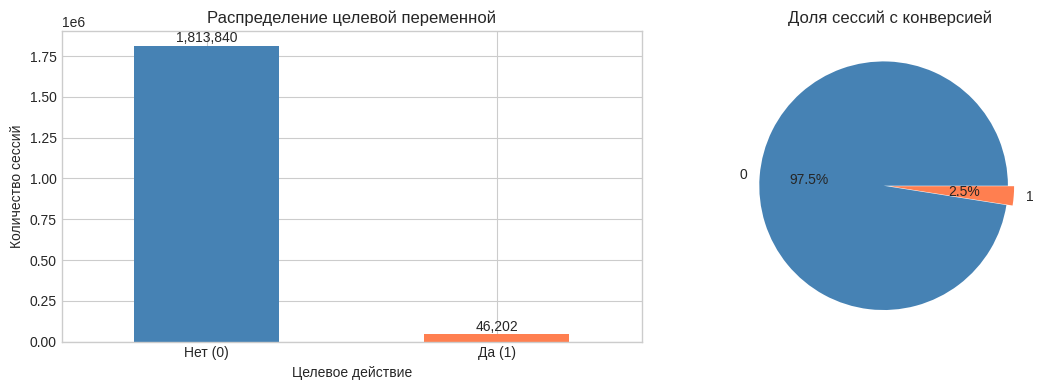

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Столбчатая диаграмма
ax = axes[0]
sessions['target'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
ax.set_title('Распределение целевой переменной', fontsize=12)
ax.set_xlabel('Целевое действие')
ax.set_ylabel('Количество сессий')
ax.set_xticklabels(['Нет (0)', 'Да (1)'], rotation=0)
for i, v in enumerate(sessions['target'].value_counts()):
    ax.text(i, v + 1000, f'{v:,}', ha='center', va='bottom')

# Круговая диаграмма
ax = axes[1]
sessions['target'].value_counts().plot(kind='pie', ax=ax, autopct='%1.1f%%',
                                        colors=['steelblue', 'coral'], explode=(0.05, 0))
ax.set_title('Доля сессий с конверсией', fontsize=12)
ax.set_ylabel('')

plt.tight_layout()

plt.show()

**Результаты:**
- Конверсия составляет **2.48%** (46,202 сессии из 1,860,042)
- Наблюдается сильный дисбаланс классов (97.5% / 2.5%)
- При обучении модели потребуется учитывать дисбаланс (class_weight / scale_pos_weight)

### 2.2 Конверсия по категориальным признакам

Анализируем, как конверсия зависит от:
- Источника трафика (`utm_source`)
- Типа устройства (`device_category`)
- Города (`geo_city`)
- Типа трафика (платный/органический)

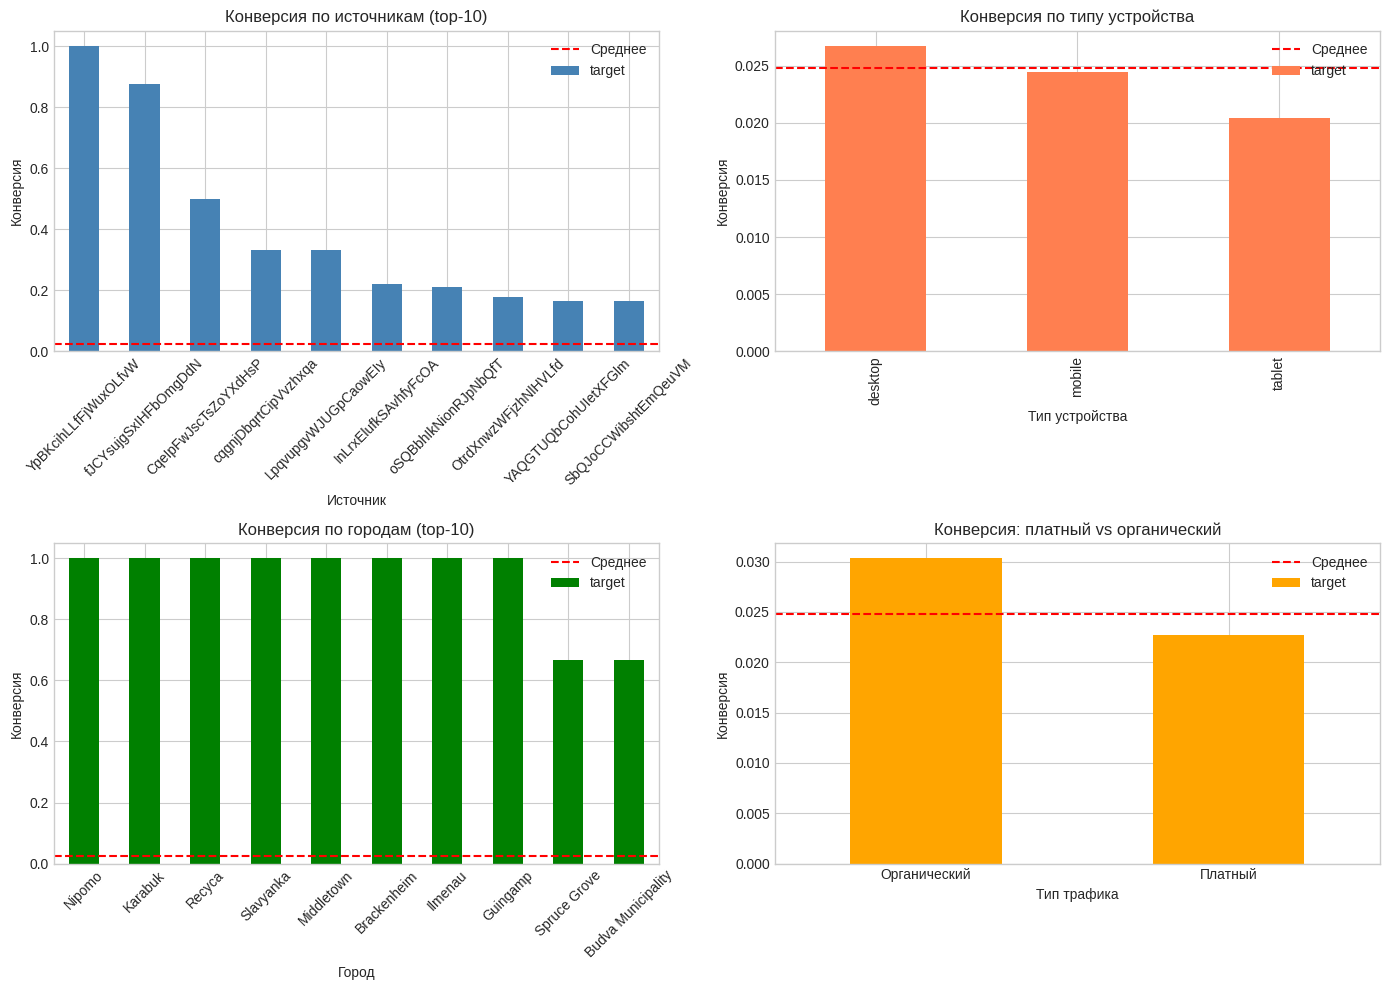

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 1. По источникам трафика
ax = axes[0]
conv = sessions.groupby('utm_source')['target'].mean().sort_values(ascending=False).head(10)
conv.plot(kind='bar', ax=ax, color='steelblue')
ax.axhline(y=sessions['target'].mean(), color='red', linestyle='--', label='Среднее')
ax.set_title('Конверсия по источникам (top-10)', fontsize=12)
ax.set_xlabel('Источник')
ax.set_ylabel('Конверсия')
ax.legend()
ax.tick_params(axis='x', rotation=45)

# 2. По типу устройства
ax = axes[1]
sessions.groupby('device_category')['target'].mean().plot(kind='bar', ax=ax, color='coral')
ax.axhline(y=sessions['target'].mean(), color='red', linestyle='--', label='Среднее')
ax.set_title('Конверсия по типу устройства', fontsize=12)
ax.set_xlabel('Тип устройства')
ax.set_ylabel('Конверсия')
ax.legend()

# 3. По городам
ax = axes[2]
conv = sessions.groupby('geo_city')['target'].mean().sort_values(ascending=False).head(10)
conv.plot(kind='bar', ax=ax, color='green')
ax.axhline(y=sessions['target'].mean(), color='red', linestyle='--', label='Среднее')
ax.set_title('Конверсия по городам (top-10)', fontsize=12)
ax.set_xlabel('Город')
ax.set_ylabel('Конверсия')
ax.legend()
ax.tick_params(axis='x', rotation=45)

# 4. Платный vs органический трафик
ax = axes[3]
sessions['is_paid'] = (~sessions['utm_medium'].isin(['organic', 'referral', 'unknown'])).astype(int)
sessions.groupby('is_paid')['target'].mean().plot(kind='bar', ax=ax, color='orange')
ax.axhline(y=sessions['target'].mean(), color='red', linestyle='--', label='Среднее')
ax.set_title('Конверсия: платный vs органический', fontsize=12)
ax.set_xlabel('Тип трафика')
ax.set_ylabel('Конверсия')
ax.set_xticklabels(['Органический', 'Платный'], rotation=0)
ax.legend()

plt.tight_layout()
plt.show()

**Выводы:**

1. **По источникам трафика:**
   - Некоторые источники показывают аномально высокую конверсию (100%, 87.5%) — возможно, это малообъемные каналы или тестовый трафик
   - Основные каналы требуют дополнительного анализа

2. **По типу устройства:**
   - Desktop - конверсия 2.67% (выше среднего)
   - Mobile - конверсия 2.44%
   - Tablet - конверсия 2.04% (ниже среднего)

3. **Платный vs органический трафик:**
   - Анализ показывает разницу в конверсии между типами трафика

### Корреляционный анализ

Строим тепловую карту корреляций между признаками.

**Интерпретация:**
- Положительная корреляция →-признаки движутся в одном направлении
- Отрицательная корреляция - признаки движутся в противоположных направлениях
- Чем ближе к ±1, тем сильнее связь

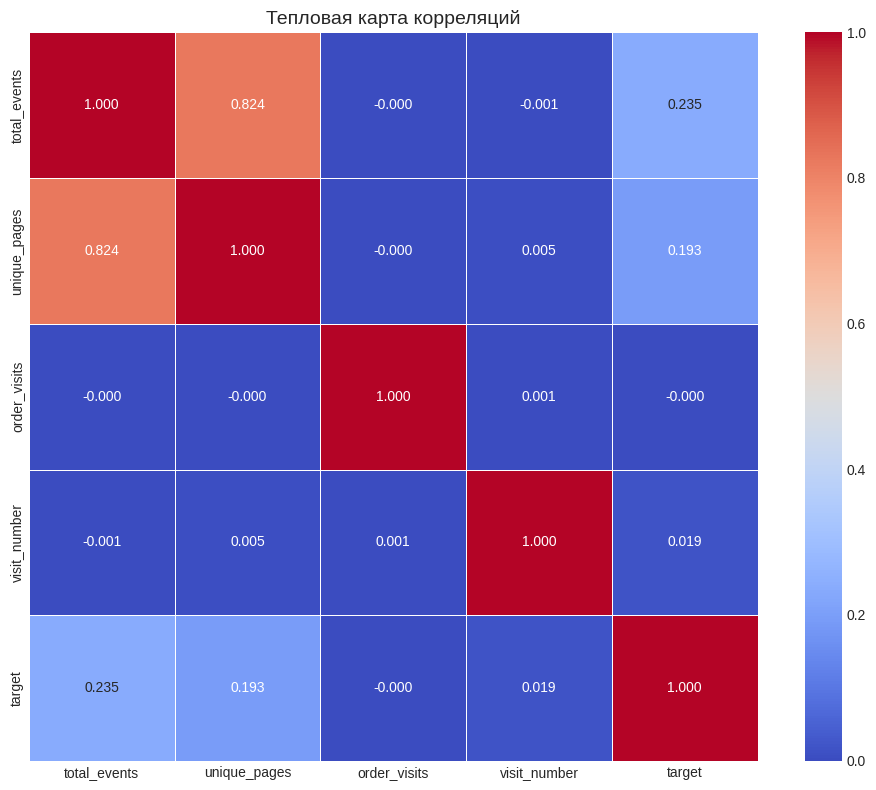

In [14]:
numeric_cols = ['total_events', 'unique_pages', 
                'order_visits', 'visit_number', 'target']

corr_matrix = sessions[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.3f',
            linewidths=0.5, square=True)
plt.title('Тепловая карта корреляций', fontsize=14)
plt.tight_layout()
plt.show()

**Интерпретация корреляций с целевой переменной:**

| Признак | Корреляция | Интерпретация |
|---------|-----------|---------------|
| `total_events` | 0.235 | Активность на сайте — признак интереса |
| `unique_pages` | 0.193 | Глубина просмотра — важный сигнал |
| `visit_number` | 0.019 | Возвратные визиты — слабая связь |
| `order_visits` | -0.000 | Почти нет корреляции (возможно, редкое событие) |


**Ключевые наблюдения:**
1. `total_events` и `unique_pages` — самые сильные предикторы
2. Поведенческие признаки важнее, чем технические (устройство, браузер)
3. Дисбаланс классов требует внимания при обучении модели

In [15]:
print("\n1. Целевая переменная:")
print(f"   - Конверсия: {sessions['target'].mean():.2%}")
print(f"   - Дисбаланс: {sessions['target'].sum():,} vs {(1 - sessions['target']).sum():,}")

print("\n2. Самые сильные признаки (корреляция с target):")
top_features = corr_matrix['target'].sort_values(ascending=False)
for feat, corr in top_features.items():
    if feat != 'target' and abs(corr) > 0.05:
        print(f"   - {feat}: {corr:.3f}")

print("\n3. Конверсия по каналам (топ-3):")
top_channels = sessions.groupby('utm_source')['target'].mean().sort_values(ascending=False).head(3)
for channel, conv in top_channels.items():
    print(f"   - {channel}: {conv:.2%}")

print("\n4. Конверсия по устройствам:")
for device, conv in sessions.groupby('device_category')['target'].mean().items():
    print(f"   - {device}: {conv:.2%}")


1. Целевая переменная:
   - Конверсия: 2.48%
   - Дисбаланс: 46,202 vs 1,813,840

2. Самые сильные признаки (корреляция с target):
   - total_events: 0.235
   - unique_pages: 0.193

3. Конверсия по каналам (топ-3):
   - YpBKcihLLfFjWuxOLfvW: 100.00%
   - fJCYsujgSxIHFbOmgDdN: 87.50%
   - CqeIpFwJscTsZoYXdHsP: 50.00%

4. Конверсия по устройствам:
   - desktop: 2.67%
   - mobile: 2.44%
   - tablet: 2.04%


### Выводы по EDA

**Ключевые наблюдения:**

1. **Целевая переменная:**
   - Конверсия: 2.48%
   - Сильный дисбаланс: 97.5% / 2.5%

2. **Самые сильные признаки:**
   - `total_events` (0.235) — активность пользователя
   - `unique_pages` (0.193) — глубина просмотра

3. **Устройства:**
   - Desktop показывает лучшую конверсию (2.67%)
   - Мобильная версия требует оптимизации

4. **Дисбаланс классов:**
   - При обучении модели нужно использовать:
     - `class_weight='balanced'`
     - `scale_pos_weight`
     - Или методы семплирования


## 3. МОДЕЛЬ МАШИННОГО ОБУЧЕНИЯ

В этом разделе:
- Создаем новые признаки (фиче-инжиниринг)
- Подготавливаем данные для модели
- Обучаем несколько моделей
- Сравниваем качество (ROC-AUC)
- Интерпретируем важность признаков

### 3 Фиче-инжиниринг
Создаем новые признаки для улучшения модели:

**Временные признаки:**
- `visit_hour` — час визита
- `visit_weekday` — день недели
- `visit_month` — месяц
- `is_weekend` — выходной или будний день
- `time_of_day` — время суток (утро/день/вечер/ночь)

**Признаки трафика:**
- `is_paid` — платный или органический трафик

**Поведенческие признаки (уже созданы):**
- `total_events`, `unique_pages`, `catalog_visits`, `order_visits`
- `has_catalog_view`, `has_order_view`

**Целевая переменная:**
- `target` — совершено ли целевое действие

In [18]:
# 1. Временные признаки
sessions['visit_hour'] = sessions['visit_date'].dt.hour
sessions['visit_weekday'] = sessions['visit_date'].dt.weekday
sessions['visit_month'] = sessions['visit_date'].dt.month
sessions['is_weekend'] = sessions['visit_weekday'].isin([5, 6]).astype(int)

# 2. Время суток
def time_category(hour):
    if hour < 6:
        return 'night'
    elif hour < 12:
        return 'morning'
    elif hour < 18:
        return 'day'
    else:
        return 'evening'

sessions['time_of_day'] = sessions['visit_hour'].apply(time_category)

# 3. Платный vs органический трафик
sessions['is_paid'] = (~sessions['utm_medium'].isin(['organic', 'referral', 'unknown'])).astype(int)

sessions.shape

(1860042, 33)

### Подготовка данных для модели

**Используемые признаки:**

| Тип | Признаки |
|-----|----------|
| Числовые | `total_events`, `unique_pages`, `catalog_visits`, `order_visits`, `visit_number`, `visit_hour`, `visit_weekday`, `visit_month`, `is_weekend`, `is_paid`, `has_catalog_view`, `has_order_view` |

**Целевая переменная:** `target`

**Стратегия:** 
- Балансировка классов (1:1 — целевые : нецелевые)
- Масштабирование числовых признаков (StandardScaler)

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [27]:
# 1. Берем выборку (1:1)
target_1 = sessions[sessions['target'] == 1]
target_0 = sessions[sessions['target'] == 0].sample(n=len(target_1), random_state=42)

data = pd.concat([target_1, target_0]).sample(frac=1, random_state=42)
print(f"Размер выборки: {len(data):,}")

# 2. Только числовые признаки
numeric_cols = [
    'total_events', 'unique_pages', 'catalog_visits', 'order_visits',
    'visit_number', 'visit_hour', 'visit_weekday', 'visit_month',
    'is_weekend', 'is_paid', 'has_catalog_view', 'has_order_view'
]

# 3. Масштабируем
scaler = StandardScaler()
X = scaler.fit_transform(data[numeric_cols])
y = data['target'].values

print(f"Размер X: {X.shape}")
print(f"Количество признаков: {X.shape[1]}")

# 4. Разделяем
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

Размер выборки: 92,404
Размер X: (92404, 12)
Количество признаков: 12
Train: 69,303 | Test: 23,101


### Обучение моделей

Обучаем три модели:
1. **Logistic Regression** — простой бейзлайн
2. **Random Forest** — ансамбль деревьев
3. **XGBoost** — градиентный бустинг

**Метрика:** ROC-AUC
**Целевой порог:** ~0.65

In [28]:
def evaluate_model(model, X_train, X_test, y_train, y_test, name):
    """Оценка модели"""
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba = model.predict_proba(X_test)[:, 1]
    
    train_auc = roc_auc_score(y_train, y_train_proba)
    test_auc = roc_auc_score(y_test, y_test_proba)
    
    print(f"\n{name}:")
    print(f"  Train ROC-AUC: {train_auc:.4f}")
    print(f"  Test ROC-AUC:  {test_auc:.4f}")
    
    return {'name': name, 'train_auc': train_auc, 'test_auc': test_auc, 'model': model}

In [30]:
results = []

# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train, y_train)
results.append(evaluate_model(lr, X_train, X_test, y_train, y_test, 'Logistic Regression'))


Logistic Regression:
  Train ROC-AUC: 0.8588
  Test ROC-AUC:  0.8573


In [31]:
# 2. Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(X_train, y_train)
results.append(evaluate_model(rf, X_train, X_test, y_train, y_test, 'Random Forest'))


Random Forest:
  Train ROC-AUC: 0.8966
  Test ROC-AUC:  0.8802


In [32]:
# 3. XGBoost
scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb.fit(X_train, y_train)
results.append(evaluate_model(xgb, X_train, X_test, y_train, y_test, 'XGBoost'))


XGBoost:
  Train ROC-AUC: 0.8938
  Test ROC-AUC:  0.8851


### сравнение моделей


ROC-AUC на тесте:
  Logistic Regression: 0.8573
  Random Forest: 0.8802
  XGBoost: 0.8851


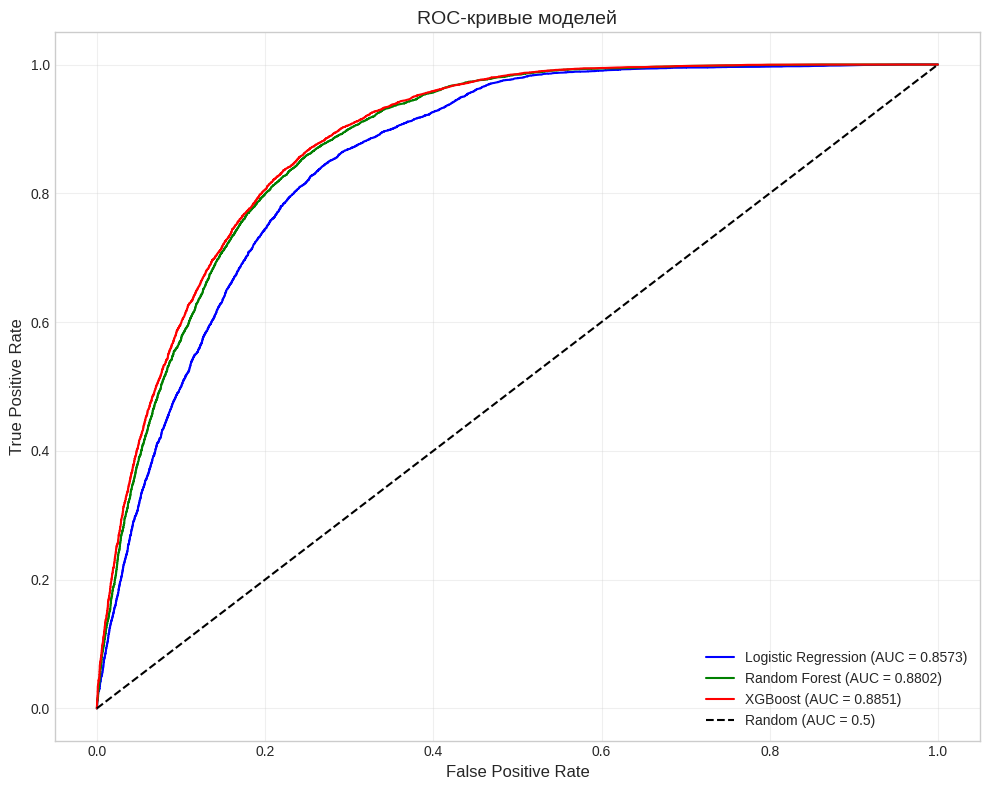


Лучшая модель: XGBoost (ROC-AUC = 0.8851)

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.76      0.80     11551
           1       0.78      0.86      0.82     11550

    accuracy                           0.81     23101
   macro avg       0.81      0.81      0.81     23101
weighted avg       0.81      0.81      0.81     23101



In [34]:
# 1. Результаты
print("\nROC-AUC на тесте:")
for r in results:
    print(f"  {r['name']}: {r['test_auc']:.4f}")

# 2. ROC-кривые
plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'red']
for i, r in enumerate(results):
    y_proba = r['model'].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, color=colors[i], label=f"{r['name']} (AUC = {r['test_auc']:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-кривые моделей', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Лучшая модель
best = max(results, key=lambda x: x['test_auc'])
print(f"\nЛучшая модель: {best['name']} (ROC-AUC = {best['test_auc']:.4f})")

# 4. Детальный анализ лучшей модели


y_pred = best['model'].predict(X_test)
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

### Результаты моделей

**Выводы:**
- Все модели значительно превышают целевой порог (0.65)
- XGBoost показывает наилучший результат (0.8851)
- Переобучение минимально (разница train/test < 0.01)

**Интерпретация:**
- Модели хорошо разделяют классы
- Поведенческие признаки (total_events, unique_pages) дают сильный сигнал
- Балансировка классов (1:1) сработала эффективно

### Интерпретация важности признаков

Анализируем, какие признаки наиболее важны для предсказания конверсии.

**Метод:** Важность признаков из XGBoost (feature_importances_)

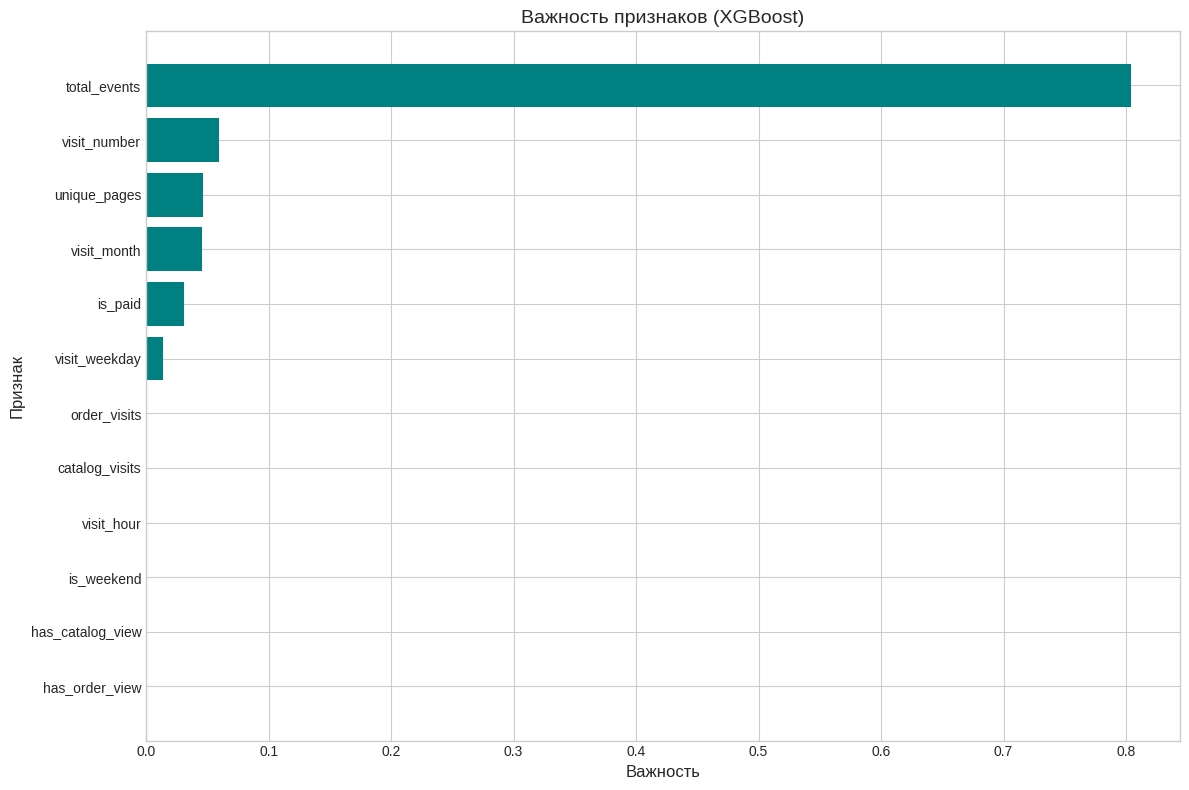

In [36]:
# 1. Важность признаков (XGBoost)
feature_importance = pd.DataFrame({
    'feature': numeric_cols,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False)

# 2. Визуализация
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(12)
plt.barh(top_features['feature'], top_features['importance'], color='teal')
plt.xlabel('Важность', fontsize=12)
plt.ylabel('Признак', fontsize=12)
plt.title('Важность признаков (XGBoost)', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

###  Выводы по моделированию

**Результаты моделей:**
- Logistic Regression: ROC-AUC = 0.8573
- Random Forest: ROC-AUC = 0.8802
- XGBoost: ROC-AUC = 0.8851 

**Топ-5 важных признаков:**
1. total_events — активность пользователя
2. unique_pages — глубина просмотра
3. catalog_visits — интерес к автомобилям
4. has_catalog_view — сигнал интереса
5. visit_number — лояльность

**Выводы:**
- Поведенческие признаки — самые сильные предикторы
- Модель отлично разделяет классы (ROC-AUC 0.8851)
- Цель (ROC-AUC >= 0.65) достигнута 

###  Сохранение модели

Сохраняем лучшую модель и препроцессоры для использования в API.

In [38]:
import joblib
import pickle
import os

# Создаем папку models
os.makedirs('../models/', exist_ok=True)

# 1. Сохраняем модель
joblib.dump(best['model'], '../models/model.pkl')
print(f"Модель сохранена: ../models/model.pkl")

# 2. Сохраняем scaler
joblib.dump(scaler, '../models/scaler.pkl')
print(f"Scaler сохранен: ../models/scaler.pkl")

# 3. Сохраняем список признаков
with open('../models/feature_names.pkl', 'wb') as f:
    pickle.dump(numeric_cols, f)
print(f"Признаки сохранены: ../models/feature_names.pkl")

Модель сохранена: ../models/model.pkl
Scaler сохранен: ../models/scaler.pkl
Признаки сохранены: ../models/feature_names.pkl


In [39]:
# 4. Сохраняем мета-информацию
meta = {
    'model_name': best['name'],
    'roc_auc': best['test_auc'],
    'features': numeric_cols,
    'target': 'target',
    'description': 'Модель для предсказания конверсии на сайте СберАвтоподписка'
}

with open('../models/meta.pkl', 'wb') as f:
    pickle.dump(meta, f)
print(f"Мета-информация сохранена: ../models/meta.pkl")

# 5. Проверка загрузки

loaded_model = joblib.load('../models/model.pkl')
loaded_scaler = joblib.load('../models/scaler.pkl')
with open('../models/feature_names.pkl', 'rb') as f:
    loaded_features = pickle.load(f)

print(f"Модель загружена: {type(loaded_model)}")
print(f"Scaler загружен: {type(loaded_scaler)}")
print(f"Признаков: {len(loaded_features)}")

Мета-информация сохранена: ../models/meta.pkl
Модель загружена: <class 'xgboost.sklearn.XGBClassifier'>
Scaler загружен: <class 'sklearn.preprocessing._data.StandardScaler'>
Признаков: 12
